## Семинар 5: "Улучшение сходимости нейросетей"

ФИО: Зверьков Егор Алексеевич

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision import transforms
%matplotlib inline

## Описание задания:
Вам необходимо реализовать оставшиеся методы из лекции и сравнить их на примере из семинара.

## Задание разделено на следующие части:
1. Реализация Xavier **(1 балл)**

2.1 Реализация DropConnect **(1 балл)**

2.2 Сравнение обучения при использовании Dropout и DropConnect **(1 балл)**

3.1 Реализация LayerNorm **(1 балл)**

3.2 Сравнение обучения при использовании BatchNorm и LayerNorm **(1 балл)**

## Срок выполнения задания:
Данное задание можно сдать без штрафов до 16 октября.


### Часть 1: Инициализация весов

Будем использовать MNIST для обучения:

In [ ]:
# Dataloader
to_numpy = lambda x: x.numpy()
transform = transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                    ])
train_dataset = MNIST('.', train=True, download=True, transform=transform)
test_dataset = MNIST('.', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.57MB/s]


In [ ]:
images_train, labels_train = next(iter(train_loader))

In [ ]:
## Usage example:
for X, y in train_loader:
    X = X.view(X.size(0), -1)
    X = X.numpy() ### Converts torch.Tensor to numpy array
    y = y.numpy()
    break

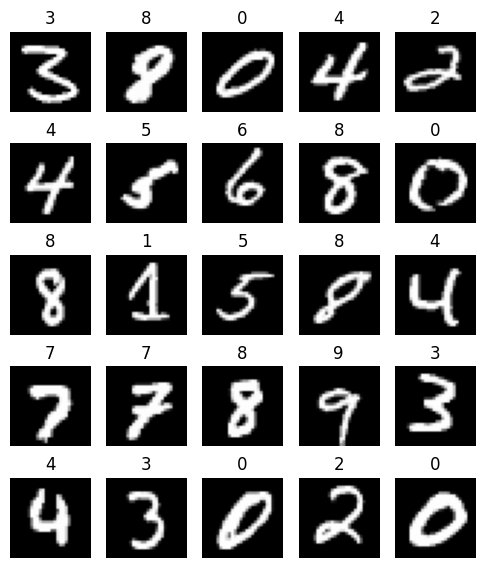

In [ ]:
plt.figure(figsize=(6, 7))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(X[i].reshape(28, 28), cmap=plt.cm.Greys_r)
    plt.title(y[i])
    plt.axis('off')

In [ ]:
def init_layer_he(layer, mean=0, std=1):
    # Тут надо быть аккуратным — можно случайно создать копию и менять значения у копии
    weight = layer.state_dict()['weight']
    bias = layer.state_dict()['bias']
    bias.zero_()
    weight.normal_(mean=0, std=std)

def forward_hook_he(self, input_, output):
    std = input_[0].std().item()
    print('forward', std)

def backward_hook_he(self, grad_input, grad_output):
    std = grad_input[0].std().item()
    print('backward', std)

На вход передаем изображение 28x28, на выходе -- вероятности 10 классов.

In [ ]:
layer_he_1 = nn.Linear(28*28, 500)
layer_he_2 = nn.Linear(500, 10)

layer_he_1.register_forward_hook(forward_hook_he)
layer_he_2.register_forward_hook(forward_hook_he)

layer_he_1.register_backward_hook(backward_hook_he)
layer_he_2.register_backward_hook(backward_hook_he)

init_layer_he(layer_he_1, 0.0, 2 / 784)
init_layer_he(layer_he_2, 0.0, 2 / 500)

Соберем все вместе, используя ReLU в качестве функции активации:

In [ ]:
network_he = nn.Sequential(
    layer_he_1,
    nn.ReLU(),
    layer_he_2
)

Попробуем использовать инициализацию He:

In [ ]:
n_objects = 100
X = images_train[:n_objects].view(n_objects, -1).data
y = labels_train[:n_objects].data
activations = network_he(X)
loss_fn = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(network_he.parameters(), lr=0.001)
loss = loss_fn(activations, y)
loss.backward()

forward 1.003989815711975
forward 0.041985806077718735
backward 0.03197220712900162
backward 0.000769864534959197


#### 1.1 Реализуйте инициализацию Xavier. Сравните ее с He, которая была реализована на семинаре, сделайте выводы. Учтите, что для Xavier необходимо использовать функцию активации nn.Tanh(). **(1 балл)**

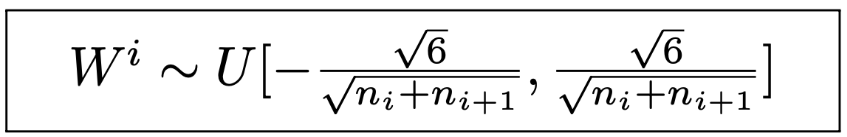

In [ ]:
def init_layer_xavier_weights(layer):
    in_features = layer.in_features
    out_features = layer.out_features
    weights = layer.state_dict()['weight']
    bias = layer.state_dict()['bias']
    bias.zero_()
    weights.uniform_(6**0.5 / (in_features +  out_features)**0.5, 6**0.5 / (in_features + out_features)**0.5)

def forward_hook_xavier(self, input_, output):
    std = input_[0].std().item()
    print('forward', std)

def backward_hook_xavier(self, grad_input, grad_output):
    std = grad_input[0].std().item()
    print('backward', std)

**Инициализация**

In [ ]:
layer_xavier_1 = nn.Linear(28*28, 500)
layer_xavier_2 = nn.Linear(500, 10)

layer_xavier_1.register_forward_hook(forward_hook_xavier)
layer_xavier_2.register_forward_hook(forward_hook_xavier)

layer_xavier_1.register_backward_hook(backward_hook_xavier)
layer_xavier_2.register_backward_hook(backward_hook_xavier)

init_layer_xavier_weights(layer_xavier_1)
init_layer_xavier_weights(layer_xavier_2)

In [ ]:
network_xavier = nn.Sequential(
    layer_xavier_1,
    nn.Tanh(),
    layer_xavier_2
)

In [ ]:
n_objects = 100
X = images_train[:n_objects].view(n_objects, -1).data
y = labels_train[:n_objects].data
activations = network_xavier(X)
loss_fn = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(network_xavier.parameters(), lr=0.001)
loss = loss_fn(activations, y)
loss.backward()

forward 1.003989815711975
forward 0.9479895234107971
backward 0.03197220712900162
backward 3.9083629665981334e-09


Xavier инициализация дает более устойчивое распространение сигнала

## Часть 2: DropConnect

#### 2.1 Реализуйте DropConnect по следующему шаблону: **(1 балл)**

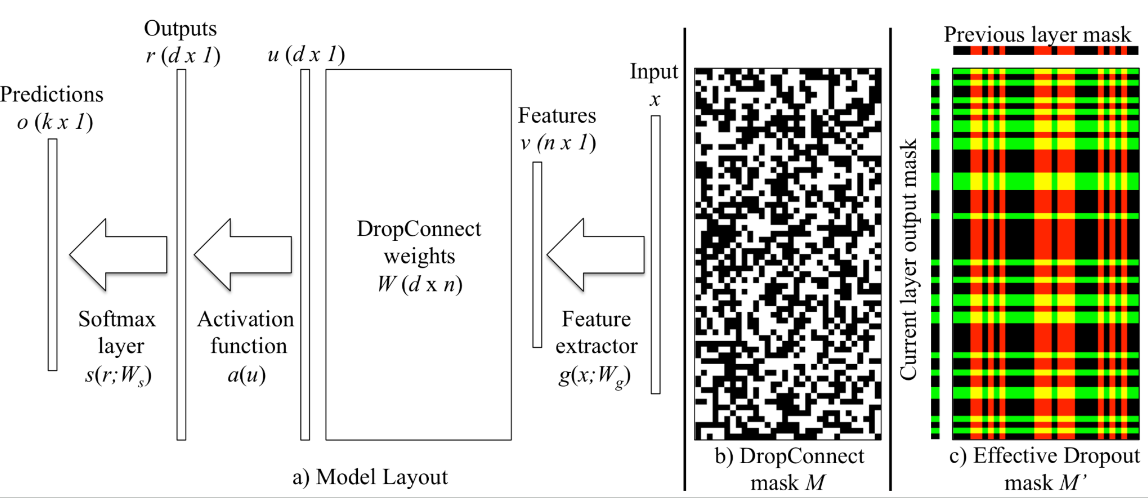

In [ ]:
# полезная функция: .bernoulli_(p)
# не забывайте делать requires_grad=False у маски
# помните, что в вычислениях должны участвовать Variable, а не тензоры

class DropConnect(nn.Module):
    def __init__(self, input_dim, output_dim, p=0.5):
        super(DropConnect, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.p = p

    def forward(self, x):
        if self.training:
            mask = torch.ones_like(self.linear.weight).bernoulli_(1 - self.p)
            mask = Variable(mask, requires_grad=False)
        else:
            mask = Variable(torch.ones_like(self.linear.weight), requires_grad=False)

        mask = mask.data
        output = F.linear(x, self.linear.weight * mask, self.linear.bias)
        return output

In [ ]:
class Dropout(nn.Module):
    def __init__(self, p=0.5):
        super(Dropout, self).__init__()
        self.p = p

    def forward(self, x):
        mask = torch.empty(x.shape).uniform_(0, 1).type(torch.FloatTensor)
        if self.training:
            mask = torch.where(mask > self.p, 1, 0)
        else:
            mask = torch.where(mask > self.p, 1, 1 - self.p)

        return x * mask

Основа для сети, которую будем обучать:

In [ ]:
class TestNetwork(nn.Module):
    def __init__(self, final_part):
        super().__init__()

        channels = 1

        self.conv_layers = nn.Sequential(
            nn.Conv2d(channels, 2, 3, padding=1),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Conv2d(2, 4, 3, padding=1),
            nn.MaxPool2d(2),
            nn.ReLU(),
        )

        #input_size = 7 * 7 * 4 = 196
        self.flatten = nn.Flatten()

        self.final_part = final_part

        self.log_softmax = nn.LogSoftmax(1)

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        x = self.final_part(x)
        return self.log_softmax(x)

**DropConnect**

In [ ]:
layers = [
    DropConnect(196, 128),
    nn.ReLU(),
    DropConnect(128, 128),
    nn.ReLU(),
    DropConnect(128, 10)
]

In [ ]:
network = TestNetwork(nn.Sequential(*layers))
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss_fn = torch.nn.NLLLoss()

Обучим получившуюся сеть:

In [ ]:
dropconnect_losses_train = []
dropconnect_losses_test = []
for epoch in range(10):
    network.train()
    losses_train_tmp = []
    for batch_idx, (images_train, labels_train) in enumerate(train_loader):
        optimizer.zero_grad()
        X = images_train.data
        y = labels_train.data
        output = network(X)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()
        losses_train_tmp.append(loss.item())

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
            epoch, batch_idx * len(X), len(train_loader.dataset),
            100. * batch_idx / len(train_loader), loss.item()))

    dropconnect_losses_train.append(np.mean(losses_train_tmp))

    network.eval()
    losses_test_tmp = []
    for batch_idx, (images_test, labels_test) in enumerate(test_loader):
        X = images_test.data
        y = labels_test.data
        output = network(X)
        loss = loss_fn(output, y)

        losses_test_tmp.append(loss.item())

    print('Test Epoch: {}\tLoss: {:.6f}'.format(
            epoch, np.mean(losses_test_tmp)))
    dropconnect_losses_test.append(np.mean(losses_test_tmp))


Train Epoch: 0 [0/60000 (0%)]	Loss: 2.297242
Train Epoch: 0 [12800/60000 (21%)]	Loss: 1.683097
Train Epoch: 0 [25600/60000 (43%)]	Loss: 1.475533
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.964664
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.849460
Test Epoch: 0	Loss: 1.696681
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.812599
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.690451
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.622462
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.565634
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.543641
Test Epoch: 1	Loss: 1.237547
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.531389
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.568914
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.305632
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.641729
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.390622
Test Epoch: 2	Loss: 1.045857
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.307651
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.245847
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.428396
Train Epoch: 3 [38400/60000 (64%)

**DropOut**

In [ ]:
layers = [
    nn.Linear(196, 128),
    nn.ReLU(),
    Dropout(),
    nn.Linear(128, 128),
    nn.ReLU(),
    Dropout(),
    nn.Linear(128, 10)
]

In [ ]:
network = TestNetwork(nn.Sequential(*layers))
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss_fn = torch.nn.NLLLoss()

In [ ]:
dropout_losses_train = []
dropout_losses_test = []
for epoch in range(10):
    network.train()
    losses_train_tmp = []
    for batch_idx, (images_train, labels_train) in enumerate(train_loader):
        optimizer.zero_grad()
        X = images_train.data
        y = labels_train.data
        output = network(X)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()
        losses_train_tmp.append(loss.item())

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
            epoch, batch_idx * len(X), len(train_loader.dataset),
            100. * batch_idx / len(train_loader), loss.item()))

    dropout_losses_train.append(np.mean(losses_train_tmp))

    network.eval()
    losses_test_tmp = []
    for batch_idx, (images_test, labels_test) in enumerate(test_loader):
        X = images_test.data
        y = labels_test.data
        output = network(X)
        loss = loss_fn(output, y)

        losses_test_tmp.append(loss.item())

    print('Test Epoch: {}\tLoss: {:.6f}'.format(
            epoch, np.mean(losses_test_tmp)))
    dropout_losses_test.append(np.mean(losses_test_tmp))


Train Epoch: 0 [0/60000 (0%)]	Loss: 2.298401
Train Epoch: 0 [12800/60000 (21%)]	Loss: 1.041160
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.630529
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.435728
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.498259
Test Epoch: 0	Loss: 0.293234
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.404983
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.325577
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.294868
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.329389
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.208026
Test Epoch: 1	Loss: 0.223249
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.245684
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.177908
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.155535
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.203361
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.222850
Test Epoch: 2	Loss: 0.200039
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.209625
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.230799
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.198580
Train Epoch: 3 [38400/60000 (64%)


#### 2.2 Сравните графики обучения нейроных сетей **(1 балл)**:
1. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и Dropout между всеми слоями
2. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и DropConnect вместо всех линейных слоев


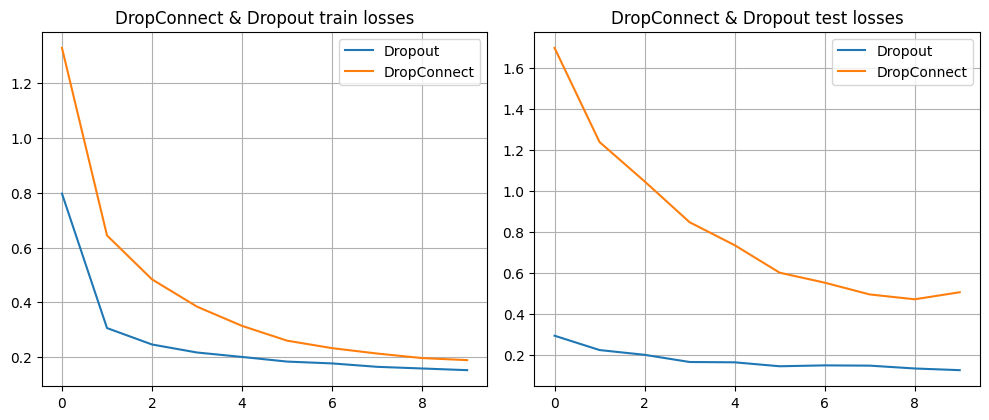

In [ ]:
epochs = np.arange(0, 10, 1)

figure = plt.figure(figsize = (10, 8))

# train
figure.add_subplot(2, 2, 1)
plt.plot(epochs, dropout_losses_train, label = 'Dropout')
plt.plot(epochs, dropconnect_losses_train, label = 'DropConnect')
plt.title('DropConnect & Dropout train losses')
plt.legend()
plt.grid()

figure.add_subplot(2, 2, 2)
plt.plot(epochs, dropout_losses_test, label = 'Dropout')
plt.plot(epochs, dropconnect_losses_test, label = 'DropConnect')
plt.title('DropConnect & Dropout test losses')
plt.legend()
plt.grid()


plt.tight_layout()
plt.show()

При использовании регуляризации DropConnect loss получается больше чем при Dropout

### Часть 3: Batch Normalization

Наконец, давайте рассмотрим Batch Normalization. Этот слой вычитает среднее и делит на стандартное отклонение. Среднее и дисперсия вычисляются по батчу независимо для каждого нейрона. У этого слоя есть две важные проблемы: его нельзя использовать при обучении с размером батча 1 и он делает элементы батча зависимыми. Давайте реализуем аналог батч нормализации: <a href=https://arxiv.org/pdf/1607.06450.pdf>Layer normalization</a>. В layer normalization среднее и дисперсия вычисляются по активациям нейронов, независимо для каждого объекта.

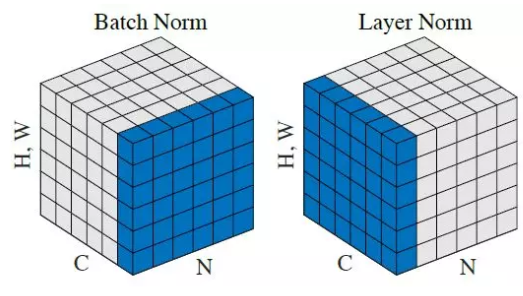

#### 3.1 Реализуйте Layer Normalization **(1 балл)**

In [ ]:
# полезные функции: .std(dim), .mean(dim)

class LayerNormalization(nn.Module):
    def __init__(self, eps=1e-5):
        super(LayerNormalization, self).__init__()
        self.eps = eps

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        std = x.std(dim=-1, keepdim=True)
        output = (x - mean) / (std + self.eps)
        return output

#### 3.2 Сравните графики обучения нейроных сетей **(1 балл)**:
1. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и Batch normalization между всеми слоями
2. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и Layer normalization между всеми слоями

**LayerNormalization**

In [ ]:
layers = [
    nn.Linear(196, 128),
    nn.ReLU(),
    LayerNormalization(),
    nn.Linear(128, 128),
    nn.ReLU(),
    LayerNormalization(),
    nn.Linear(128, 10)
]

In [ ]:
network = TestNetwork(nn.Sequential(*layers))
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss_fn = torch.nn.NLLLoss()

In [ ]:
losses_layer_norm_train = []
losses_layer_norm_test = []
for epoch in range(10):
    network.train()
    losses_train_tmp = []
    for batch_idx, (images_train, labels_train) in enumerate(train_loader):
        optimizer.zero_grad()
        X = images_train.data
        y = labels_train.data
        output = network(X)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()
        losses_train_tmp.append(loss.item())

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
            epoch, batch_idx * len(X), len(train_loader.dataset),
            100. * batch_idx / len(train_loader), loss.item()))

    losses_layer_norm_train.append(np.mean(losses_train_tmp))

    network.eval()
    losses_test_tmp = []
    for batch_idx, (images_test, labels_test) in enumerate(test_loader):
        X = images_test.data
        y = labels_test.data
        output = network(X)
        loss = loss_fn(output, y)

        losses_test_tmp.append(loss.item())

    print('Test Epoch: {}\tLoss: {:.6f}'.format(
            epoch, np.mean(losses_test_tmp)))
    losses_layer_norm_test.append(np.mean(losses_test_tmp))

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.438143
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.461492
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.197816
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.100306
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.237679
Test Epoch: 0	Loss: 0.142648
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.080370
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.227801
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.202121
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.098914
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.103433
Test Epoch: 1	Loss: 0.124410
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.096888
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.067532
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.120264
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.084533
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.117375
Test Epoch: 2	Loss: 0.112699
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.097418
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.098087
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.115701
Train Epoch: 3 [38400/60000 (64%)

**BatchNorm1d**

In [ ]:
layers = [
    nn.Linear(196, 128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Linear(128, 10)
]

In [ ]:
network = TestNetwork(nn.Sequential(*layers))
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss_fn = torch.nn.NLLLoss()

In [ ]:
losses_batch_norm_train = []
losses_batch_norm_test = []
for epoch in range(10):
    network.train()
    losses_train_tmp = []
    for batch_idx, (images_train, labels_train) in enumerate(train_loader):
        optimizer.zero_grad()
        X = images_train.data
        y = labels_train.data
        output = network(X)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()
        losses_train_tmp.append(loss.item())

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
            epoch, batch_idx * len(X), len(train_loader.dataset),
            100. * batch_idx / len(train_loader), loss.item()))

    losses_batch_norm_train.append(np.mean(losses_train_tmp))

    network.eval()
    losses_test_tmp = []
    for batch_idx, (images_test, labels_test) in enumerate(test_loader):
        X = images_test.data
        y = labels_test.data
        output = network(X)
        loss = loss_fn(output, y)

        losses_test_tmp.append(loss.item())

    print('Test Epoch: {}\tLoss: {:.6f}'.format(
            epoch, np.mean(losses_test_tmp)))
    losses_batch_norm_test.append(np.mean(losses_test_tmp))

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.374755
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.259519
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.145487
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.072158
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.125675
Test Epoch: 0	Loss: 0.137211
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.129812
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.173504
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.071220
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.114505
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.105654
Test Epoch: 1	Loss: 0.098984
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.168421
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.034640
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.065829
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.093265
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.031795
Test Epoch: 2	Loss: 0.074579
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.016846
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.065436
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.043146
Train Epoch: 3 [38400/60000 (64%)

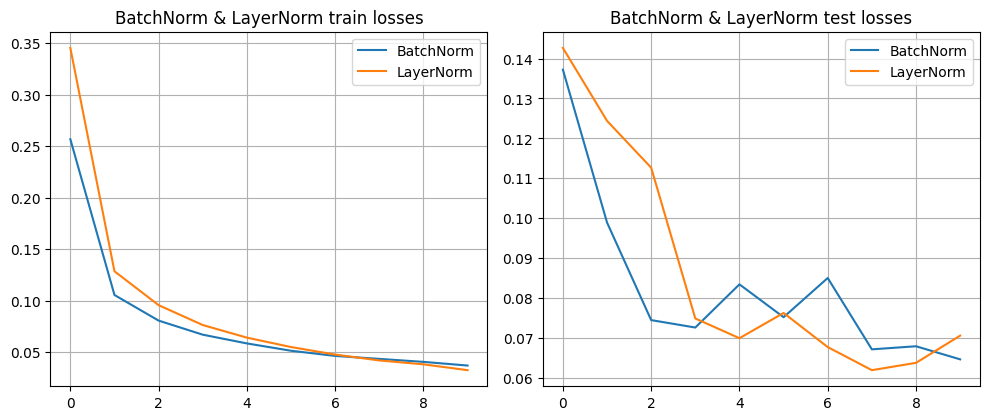

In [ ]:
epochs = np.arange(0, 10, 1)

figure = plt.figure(figsize = (10, 8))

figure.add_subplot(2, 2, 1)
plt.plot(epochs, losses_batch_norm_train, label = 'BatchNorm')
plt.plot(epochs, losses_layer_norm_train, label = 'LayerNorm')
plt.title('BatchNorm & LayerNorm train losses')
plt.legend()
plt.grid()

figure.add_subplot(2, 2, 2)
plt.plot(epochs, losses_batch_norm_test, label = 'BatchNorm')
plt.plot(epochs, losses_layer_norm_test, label = 'LayerNorm')
plt.title('BatchNorm & LayerNorm test losses')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

При нормализации LayerNorm, loss чуть больше чем при применении BatchNorm

Модели с нормализацией имеют меньший loss, чем модели с регуляризацией